['umbrella', 'fire extinguisher', 'a single traffic cone', 'luggage', 'rc car', 'pile of traffic cone']
[  0 100 101]


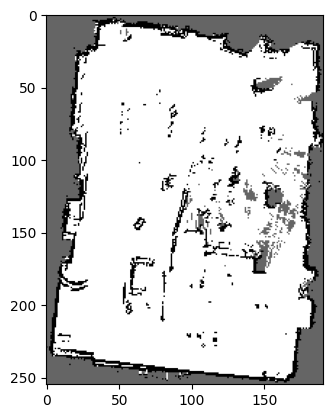

In [1]:
import cv2
import yaml
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
# os.chdir('/home/jetson/cmap/athirdmapper/exp01_0610')
os.chdir('./exp01_0610')
with open('features.pkl', 'rb') as file:
    features = pickle.load(file)
with open('features_ind.pkl', 'rb') as file:
    features_ind = pickle.load(file)
with open('text_features.pkl', 'rb') as file:
    text_features = pickle.load(file)
map_img = cv2.imread('map.pgm', cv2.IMREAD_GRAYSCALE)
with open('map.yaml', 'r') as file:
    map_data = yaml.safe_load(file)

print(text_features['list'])
print(np.unique(map_img))
_map = np.copy(map_img)
_map[_map == 100] = 255
plt.imshow(_map, cmap='gray')
# 101 = unknown space
# 0 = occupied space
# 100 = free space => 255

In [2]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
def similarity(image_features, text_features):
    if isinstance(image_features, list): image_features = np.array(image_features)
    if isinstance(text_features, list): text_features = np.array(text_features)
    if torch.cuda.is_available(): 
        return image_features @ text_features.cpu().numpy().T
    return np.dot(image_features, text_features.T)
def show_images(ind):
    for i, img_ind in enumerate(ind):
        r = len(ind)//9+1
        plt.figure('candidates', figsize=(12, r*2))
        plt.subplot(r, 9, i+1)
        img = cv2.imread('n_images/' + str(img_ind) + '.png')
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.tight_layout()
def point2pixel(point, origin, resolution):
    return (int((point[0] - origin[0]) / resolution),
            int((point[1] - origin[1]) / resolution))
def probmap(conf, map, map_data, grid_size, mode='freq'):
    d = 0 if mode == 'score' else 1
    origin = map_data['origin']
    resolution = map_data['resolution']
    max_p = max(conf.values(), key=lambda x: x[d])[d]
    min_p = min(conf.values(), key=lambda x: x[d])[d]
    grid_pixel = int(grid_size / resolution // 2)
    ret = np.copy(map)
    ret = cv2.cvtColor(ret, cv2.COLOR_GRAY2BGR)
    color = (0,0,255)
    for point, score in conf.items():
        x, y = point2pixel(point, origin, resolution)
        p = (score[d]-min_p) / (max_p-min_p)
        layer = np.copy(ret)
        layer = cv2.rectangle(layer, (x-grid_pixel,y-grid_pixel), (x+grid_pixel,y+grid_pixel), color, -1)
        ret = cv2.addWeighted(ret, 1-p, layer, p, 0)
    return ret
def get_conf(features, voxels, text_feature, th=0.01, show_candidates=False):
    similarities = similarity(features, text_feature).squeeze()*100
    softmax = F.softmax(torch.tensor(similarities), dim=0).numpy()
    m = np.sum(softmax > th)
    sim_sort_ind = np.argsort(similarities, axis=0)[::-1][:m]
    if show_candidates: show_images(sim_sort_ind)
    conf = {}
    for index in sim_sort_ind:
        # score = similarities[index]
        score = softmax[index]
        for point in features_ind[index]:
            [s, n] = conf.get(tuple(point), [0,0])
            conf[tuple(point)] = [(s * n + score) / (n + 1), n + 1]
    print(f'{m} grid points are detected')
    print('conf:', conf)
    # sort confidence by value
    # conf_score = dict(sorted(conf.items(), key=lambda item: item[1], reverse=True))
    # conf_freq = dict(sorted(conf.items(), key=lambda item: item[1][1], reverse=True))
    # k_s = list(conf_score.keys())
    # v_s = list(conf_score.values())
    # k_f = list(conf_freq.keys())
    # v_f = list(conf_freq.values())
    return conf

umbrella
33 grid points are detected
conf: {(-5.5, -0.5, 0.0): [0.025109279675027595, 11], (-5.5, -0.25, 0.0): [0.02582516566155265, 10], (-5.25, -1.25, 0.0): [0.033949098200300745, 4], (-5.0, -1.25, 0.0): [0.027635832537487737, 11], (-5.0, -0.25, 0.0): [0.02204035219845319, 23], (-4.75, -0.25, 0.0): [0.022164420727136234, 26], (-4.5, -0.25, 0.0): [0.022929681595032884, 25], (-5.25, -0.5, 0.0): [0.021510682405793038, 17], (-5.25, -0.25, 0.0): [0.026094566545013735, 4], (-5.5, 0.0, 0.0): [0.01901967981370688, 5], (-5.0, -1.5, 0.0): [0.02535492371600465, 3], (-4.5, -0.5, 0.0): [0.017639062353179365, 10], (-4.25, -0.25, 0.0): [0.021419080811382503, 4], (-5.25, -0.75, 0.0): [0.017343399721613972, 4], (-5.0, -0.5, 0.0): [0.01657495607813039, 7], (-5.5, -0.75, 0.0): [0.016423226818062596, 2], (-5.0, -1.0, 0.0): [0.016677644171095716, 3], (-4.75, -1.5, 0.0): [0.01599332367262436, 1], (-4.75, -1.25, 0.0): [0.01599332367262436, 1], (-4.75, -0.5, 0.0): [0.01388271554914526, 3], (-5.5, 0.25, 0.0)

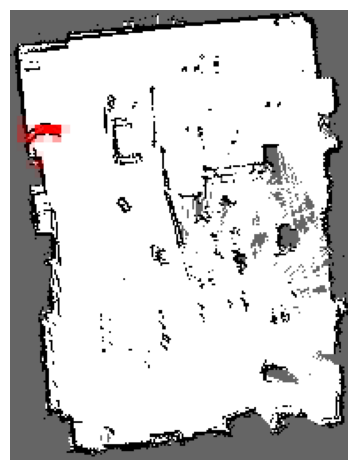

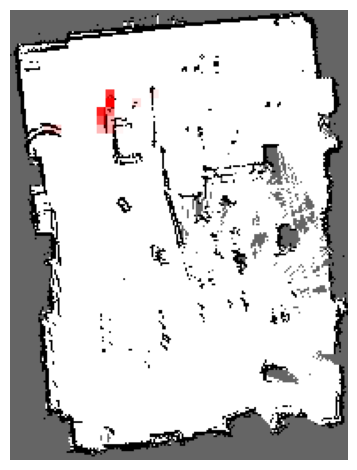

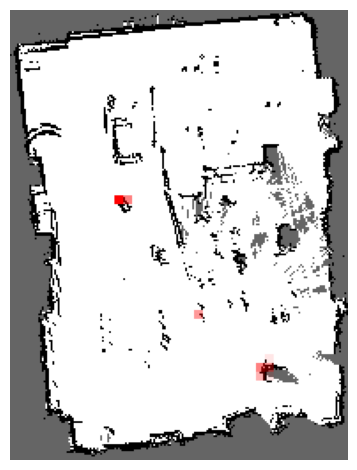

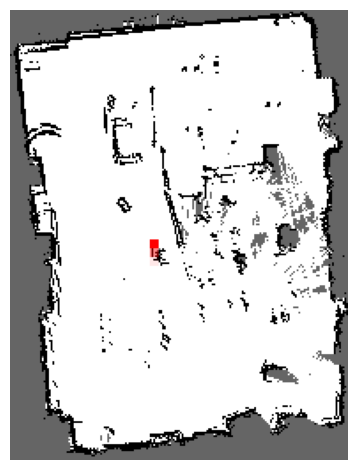

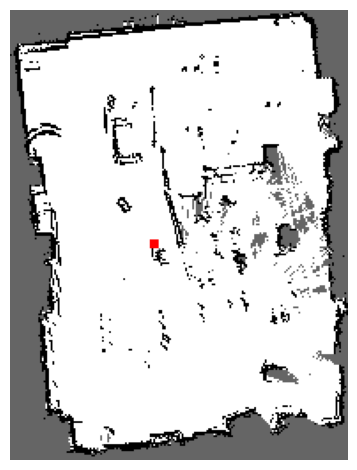

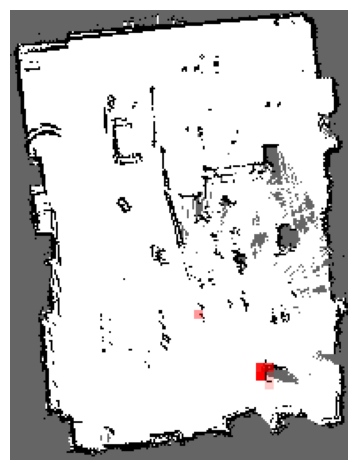

In [3]:
text_list = text_features['list']
for text in text_list:
    print(f'{text}')
    text_feature = text_features[text]
    conf = get_conf(features, features_ind, text_feature)
    probability_map = probmap(conf, _map, map_data, 0.25, 'freq')
    plt.figure(text)
    plt.axis('off')
    plt.tight_layout()
    probability_map = np.flip(probability_map, 0)
    probability_map = cv2.cvtColor(probability_map, cv2.COLOR_BGR2RGB)
    plt.imshow(probability_map)

In [4]:
os.chdir('../')
from utils import CLIP
os.chdir('../')
clip = CLIP('ViT-B-16-SigLIP')

c:\Users\Blu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Blu\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\amp\autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


22 grid points are detected
conf: {(0.75, -8.25, 0.0): [0.016935245898683317, 8], (1.0, -8.25, 0.0): [0.016142106466617994, 10], (1.5, -8.5, 0.0): [0.016030598385830156, 11], (1.75, -8.75, 0.0): [0.016619926587775464, 10], (1.75, -8.5, 0.0): [0.016030598385830156, 11], (-5.25, -1.25, 0.0): [0.032022533248523936, 1], (-5.25, -1.0, 0.0): [0.032022533248523936, 1], (-5.0, -1.75, 0.0): [0.032022533248523936, 1], (-5.0, -1.5, 0.0): [0.032022533248523936, 1], (-5.0, -1.25, 0.0): [0.032022533248523936, 1], (-5.0, -1.0, 0.0): [0.032022533248523936, 1], (-4.5, -0.25, 0.0): [0.032022533248523936, 1], (-0.25, -8.75, 0.0): [0.013745228535437318, 2], (0.0, -8.75, 0.0): [0.012585072091115382, 3], (0.25, -9.0, 0.0): [0.013745228535437318, 2], (0.25, -8.75, 0.0): [0.012585072091115382, 3], (0.25, -8.5, 0.0): [0.013745228535437318, 2], (1.75, -8.25, 0.0): [0.014344446584603137, 4], (2.0, -8.25, 0.0): [0.01357638809179309, 7], (2.0, -8.5, 0.0): [0.012917116617119175, 4], (2.25, -8.5, 0.0): [0.0133245436

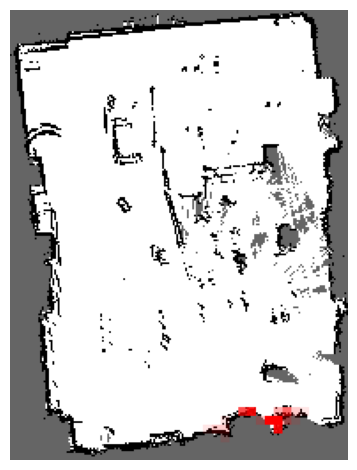

In [11]:
from IPython.display import clear_output
while True:
    try:
        clear_output(wait=True)
        string = input('Enter text: ')
        if string == '': break
        text_feature = clip.encode_text([string])
        conf = get_conf(features, features_ind, text_feature)
        probability_map = probmap(conf, _map, map_data, 0.25, 'freq')
        plt.figure(0)
        plt.axis('off')
        plt.tight_layout()
        probability_map = np.flip(probability_map, 0)
        probability_map = cv2.cvtColor(probability_map, cv2.COLOR_BGR2RGB)
        plt.imshow(probability_map)
        plt.show()
    except Exception as e:
        print(e)